<a href="https://colab.research.google.com/github/anamacao/FAPESP-PIBIC-scrapping/blob/main/edpb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re
from datetime import datetime
import sqlite3

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "colab"

In [ ]:
# %%
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"
}

BASE_URL = "https://www.edpb.europa.eu/news/news_en?news_type=1"
print("✅ Scraper do EDPB News pronto!")

✅ Scraper do EDPB News pronto!


In [ ]:
DATABASE_NAME = "internet_governance_news.db"

def create_database():
    conn = sqlite3.connect(DATABASE_NAME)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS articles (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            title TEXT,
            date TEXT,
            author TEXT,
            url TEXT UNIQUE,
            source TEXT
        )
    """)
    conn.commit()
    conn.close()
    print("✅ Banco e tabela 'articles' prontos!")

create_database()


✅ Banco e tabela 'articles' prontos!


In [ ]:
def insert_article(title, date, author, url, source):
    conn = sqlite3.connect(DATABASE_NAME)
    cursor = conn.cursor()
    try:
        cursor.execute("""
            INSERT INTO articles (title, date, author, url, source)
            VALUES (?, ?, ?, ?, ?)
        """, (title, date, author, url, source))
        conn.commit()
        return True
    except sqlite3.IntegrityError:
        return False
    finally:
        conn.close()

In [ ]:
# %%
def load_articles_from_db():
    try:
        conn = sqlite3.connect(DATABASE_NAME)
        # Garantimos que a tabela existe antes de ler
        df = pd.read_sql("""
            SELECT *
            FROM articles
            ORDER BY date DESC
        """, conn)
        conn.close()
        return df
    except Exception as e:
        print(f"⚠️ Erro ao carregar banco: {e}")
        return pd.DataFrame()

# Recarrega os dados do banco
df_db = load_articles_from_db()

if not df_db.empty:
    display(df_db.head())
    print(f"📦 Total no banco: {len(df_db)} registros")
else:
    print("⚠️ O banco de dados ainda está vazio. Verifique se a célula de coleta (scraping) foi executada com sucesso.")

,id,title,date,author,url,source
0,1,Marking 10 years of the GDPR: the evolution of...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/mark...,EDPB
1,2,Stakeholder event on competition and data prot...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/stak...,EDPB
2,3,EDPB brings clarity to data processing for sci...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/edpb...,EDPB
3,4,Enhancing compliance and consistency: EDPB ado...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/enha...,EDPB
4,5,EDPB annual report 2025: supporting stakeholde...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/edpb...,EDPB


📦 Total no banco: 300 registros


In [ ]:
# %%
def montar_url(pagina):
    """Monta a URL paginada do EDPB News (page=0 é a primeira)."""
    if pagina == 0:
        return f"{BASE_URL}?news_type=1"
    return f"{BASE_URL}?news_type=1&page={pagina}"

def extrair_paragrafos(url):
    """Acessa a página da notícia e extrai os parágrafos principais."""
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.text, "html.parser")
        ps = soup.find_all("p")
        textos = [
            p.get_text(strip=True)
            for p in ps
            if len(p.get_text(strip=True).split()) > 10
        ]
        return textos[:5] if textos else ["NA"]
    except:
        return ["NA"]

In [ ]:
# %%
noticias = []
TOTAL_PAGES = 30  # Reduzindo para teste inicial rápido

# Ajuste na URL Base para facilitar a concatenação
CLEAN_BASE_URL = "https://www.edpb.europa.eu/news/news_en"

def montar_url(pagina):
    """Monta a URL paginada correta do EDPB News."""
    params = "news_type=1"
    if pagina > 0:
        return f"{CLEAN_BASE_URL}?{params}&page={pagina}"
    return f"{CLEAN_BASE_URL}?{params}"

for pagina in range(0, TOTAL_PAGES):
    url = montar_url(pagina)
    print(f"📄 Coletando página {pagina + 1}/{TOTAL_PAGES}: {url}")

    try:
        r = requests.get(url, headers=HEADERS, timeout=15)
        if r.status_code != 200:
            print(f"⚠️ Erro HTTP {r.status_code} — parando.")
            break
    except Exception as e:
        print(f"⚠️ Erro de conexão: {e}")
        break

    soup = BeautifulSoup(r.text, "html.parser")

    # Seleciona as linhas de notícias
    itens = soup.select(".views-row")
    if not itens:
        print("🏁 Sem mais resultados ou seletores incorretos — fim da coleta.")
        break

    print(f"   {len(itens)} notícias encontradas")

    for item in itens:
        # Tenta diferentes seletores para o título e link
        titulo_tag = item.select_one("h2 a, h3 a, h4 a, .views-field-title a")

        if not titulo_tag:
            continue

        titulo = titulo_tag.get_text(strip=True)
        link = titulo_tag.get("href", "")

        if link.startswith("/"):
            link = f"https://www.edpb.europa.eu{link}"

        # Tenta capturar a data
        date_tag = item.select_one("time, .views-field-created, .date-display-single")
        data_raw = "NA"
        if date_tag:
            data_raw = date_tag.get("datetime", date_tag.get_text(strip=True))

        # Extrai parágrafos
        paragrafos = extrair_paragrafos(link)

        noticias.append({
            "titulo": titulo,
            "data": data_raw,
            "link": link,
            "paragrafos": " || ".join(paragrafos),
            "fonte": "EDPB"
        })

        # Salva no banco
        insert_article(titulo, data_raw, "EDPB", link, "EDPB")

    time.sleep(1)

print(f"\n✅ Total coletado nesta rodada: {len(noticias)} notícias")

df_edpb = pd.DataFrame(noticias)
if not df_edpb.empty:
    display(df_edpb.head())
else:
    print("❌ Nenhuma notícia foi extraída. Verifique os seletores de classe '.views-row'.")

📄 Coletando página 1/30: https://www.edpb.europa.eu/news/news_en?news_type=1
   10 notícias encontradas
📄 Coletando página 2/30: https://www.edpb.europa.eu/news/news_en?news_type=1&page=1
   10 notícias encontradas
📄 Coletando página 3/30: https://www.edpb.europa.eu/news/news_en?news_type=1&page=2
   10 notícias encontradas
📄 Coletando página 4/30: https://www.edpb.europa.eu/news/news_en?news_type=1&page=3
   10 notícias encontradas
📄 Coletando página 5/30: https://www.edpb.europa.eu/news/news_en?news_type=1&page=4
   10 notícias encontradas
📄 Coletando página 6/30: https://www.edpb.europa.eu/news/news_en?news_type=1&page=5
   10 notícias encontradas
📄 Coletando página 7/30: https://www.edpb.europa.eu/news/news_en?news_type=1&page=6
   10 notícias encontradas
📄 Coletando página 8/30: https://www.edpb.europa.eu/news/news_en?news_type=1&page=7
   10 notícias encontradas
📄 Coletando página 9/30: https://www.edpb.europa.eu/news/news_en?news_type=1&page=8
   10 notícias encontradas
📄 Coleta

,titulo,data,link,paragrafos,fonte
0,Marking 10 years of the GDPR: the evolution of...,NA,https://www.edpb.europa.eu/news/news/2026/mark...,"Brussels, 27 April – Today marks the 10th anni...",EDPB
1,Stakeholder event on competition and data prot...,NA,https://www.edpb.europa.eu/news/news/2026/stak...,"Brussels, 23 April – The EDPB is organising a ...",EDPB
2,EDPB brings clarity to data processing for sci...,NA,https://www.edpb.europa.eu/news/news/2026/edpb...,"Brussels, 16 April – During its latest plenary...",EDPB
3,Enhancing compliance and consistency: EDPB ado...,NA,https://www.edpb.europa.eu/news/news/2026/enha...,"Brussels, 14 April - In line with theEDPB’s He...",EDPB
4,EDPB annual report 2025: supporting stakeholde...,NA,https://www.edpb.europa.eu/news/news/2026/edpb...,"Brussels, 09 April - The European Data Protect...",EDPB


In [ ]:
# Listar colunas do DataFrame coletado
print(f"Colunas em df_edpb: {df_edpb.columns.tolist()}")
display(df_edpb.head(1))

Colunas em df_edpb: ['titulo', 'data', 'link', 'paragrafos', 'fonte']


,titulo,data,link,paragrafos,fonte
0,Marking 10 years of the GDPR: the evolution of...,NA,https://www.edpb.europa.eu/news/news/2026/mark...,"Brussels, 27 April – Today marks the 10th anni...",EDPB


In [ ]:
def load_articles():
    conn = sqlite3.connect(DATABASE_NAME)
    df = pd.read_sql("""
        SELECT * FROM articles
        ORDER BY date DESC
    """, conn)
    conn.close()
    return df

df_db = load_articles()
print(f"📦 Total no banco: {len(df_db)} registros")
display(df_db.head(20))

📦 Total no banco: 300 registros


,id,title,date,author,url,source
0,1,Marking 10 years of the GDPR: the evolution of...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/mark...,EDPB
1,2,Stakeholder event on competition and data prot...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/stak...,EDPB
2,3,EDPB brings clarity to data processing for sci...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/edpb...,EDPB
3,4,Enhancing compliance and consistency: EDPB ado...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/enha...,EDPB
4,5,EDPB annual report 2025: supporting stakeholde...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/edpb...,EDPB
5,6,EDPB conference on cross-regulatory cooperatio...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/edpb...,EDPB
6,7,EDPB and EDPS support strengthening EU’s cyber...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/edpb...,EDPB
7,8,CEF 2026: EDPB launches coordinated enforcemen...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/cef-...,EDPB
8,9,EDPB and EDPS support harmonisation of clinica...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/edpb...,EDPB
9,10,Stakeholder event on political advertising: ag...,NA,EDPB,https://www.edpb.europa.eu/news/news/2026/stak...,EDPB


In [29]:
keywords = ['digital', 'internet', 'IA', 'tecnologia', 'dados', 'privacidade',
            'data', 'privacy', 'GDPR', 'AI', 'protection', 'enforcement']
pattern = r'|'.join(keywords)

# Verificando se as colunas existem antes de filtrar para evitar o KeyError
if 'titulo' in df_edpb.columns and 'paragrafos' in df_edpb.columns:
    df_filt = df_edpb[
        df_edpb['titulo'].str.contains(pattern, case=False, na=False, regex=True) |
        df_edpb['paragrafos'].str.contains(pattern, case=False, na=False, regex=True)
    ].copy()

    print(f"{len(df_filt)} notícias filtradas (de {len(df_edpb)})")
    display(df_filt.head())
else:
    print(f"⚠️ Erro: Colunas esperadas não encontradas. Colunas atuais: {df_edpb.columns.tolist()}")

278 notícias filtradas (de 300)


,titulo,data,link,paragrafos,fonte
0,Marking 10 years of the GDPR: the evolution of...,NA,https://www.edpb.europa.eu/news/news/2026/mark...,"Brussels, 27 April – Today marks the 10th anni...",EDPB
1,Stakeholder event on competition and data prot...,NA,https://www.edpb.europa.eu/news/news/2026/stak...,"Brussels, 23 April – The EDPB is organising a ...",EDPB
2,EDPB brings clarity to data processing for sci...,NA,https://www.edpb.europa.eu/news/news/2026/edpb...,"Brussels, 16 April – During its latest plenary...",EDPB
3,Enhancing compliance and consistency: EDPB ado...,NA,https://www.edpb.europa.eu/news/news/2026/enha...,"Brussels, 14 April - In line with theEDPB’s He...",EDPB
4,EDPB annual report 2025: supporting stakeholde...,NA,https://www.edpb.europa.eu/news/news/2026/edpb...,"Brussels, 09 April - The European Data Protect...",EDPB


In [31]:
def plot_charts(df):
    if df.empty:
        print("❌ Sem dados para gráficos")
        return

    # Ajustando nomes de colunas para garantir compatibilidade com df_db
    # df_db tem: title, date, author, url, source

    # ------------------------------
    # Top 15 Notícias (Apenas visualização)
    # ------------------------------
    top15 = df.head(15).copy()
    top15['rank'] = range(1, len(top15) + 1)

    fig1 = px.bar(
        top15,
        y='title',
        x='id',
        orientation='h',
        title='Amostra de Notícias (IDs no Banco)',
        labels={'title': 'Título', 'id': 'ID do Registro'}
    )
    fig1.update_layout(height=600, yaxis={'categoryorder':'total ascending'})
    fig1.show()

    # ------------------------------
    # Distribuição por Fonte
    # ------------------------------
    if 'source' in df.columns:
        source_count = df["source"].value_counts().reset_index()
        source_count.columns = ["source", "count"]

        fig2 = px.pie(
            source_count,
            names="source",
            values="count",
            title="Distribuição por Fonte"
        )
        fig2.show()

    # ------------------------------
    # Nuvem de Palavras (Treemap)
    # ------------------------------
    if 'title' in df.columns:
        text = ' '.join(df['title'].astype(str)).lower()
        words = re.findall(r'\b\w{5,}\b', text) # palavras com mais de 5 letras

        wc = (
            pd.Series(words)
            .value_counts()
            .head(20)
            .reset_index()
        )
        wc.columns = ['palavra', 'freq']

        fig3 = px.treemap(
            wc,
            path=['palavra'],
            values='freq',
            title='Palavras mais frequentes nos Títulos'
        )
        fig3.show()

In [32]:
# Recarrega os dados e tenta plotar novamente com o renderizador 'colab'
df_db = load_articles_from_db()
if not df_db.empty:
    print(f'📊 Gerando gráficos para {len(df_db)} registros...')
    plot_charts(df_db)
else:
    print('⚠️ Erro: O banco de dados está vazio. Execute a célula de coleta primeiro.')

📊 Gerando gráficos para 300 registros...


In [33]:
# Teste simples de renderização
import plotly.express as px
fig = px.scatter(x=[1, 2, 3], y=[4, 1, 2], title='Teste de Renderização')
fig.show()

In [34]:
import sqlite3
import pandas as pd
import plotly.express as px
import plotly.io as pio
import re

DATABASE_NAME = "internet_governance_news.db"
# Voltando para o renderizador nativo do Colab para evitar dependências de sistema
pio.renderers.default = "colab"

def load_articles_from_db():
    try:
        conn = sqlite3.connect(DATABASE_NAME)
        df = pd.read_sql("SELECT * FROM articles ORDER BY date DESC", conn)
        conn.close()
        return df
    except Exception as e:
        print(f"⚠️ Erro ao carregar banco: {e}")
        return pd.DataFrame()

def plot_charts(df):
    if df.empty:
        print("❌ Sem dados para gráficos")
        return

    # 1. Amostra de Notícias
    top15 = df.head(15).copy()
    fig1 = px.bar(
        top15,
        y='title',
        x='id',
        orientation='h',
        title='Amostra de Notícias (IDs no Banco)',
        labels={'title': 'Título', 'id': 'ID do Registro'}
    )
    fig1.update_layout(height=600, yaxis={'categoryorder':'total ascending'})
    fig1.show()

    # 2. Distribuição por Fonte
    if 'source' in df.columns:
        source_count = df["source"].value_counts().reset_index()
        source_count.columns = ["source", "count"]
        fig2 = px.pie(source_count, names="source", values="count", title="Distribuição por Fonte")
        fig2.show()

    # 3. Nuvem de Palavras (Treemap)
    text = ' '.join(df['title'].astype(str)).lower()
    words = re.findall(r'\b\w{5,}\b', text)
    if words:
        wc = pd.Series(words).value_counts().head(20).reset_index()
        wc.columns = ['palavra', 'freq']
        fig3 = px.treemap(wc, path=['palavra'], values='freq', title='Palavras mais frequentes nos Títulos')
        fig3.show()

# Execução
df_db = load_articles_from_db()
if not df_db.empty:
    print(f"📊 Gerando visualizações para {len(df_db)} registros...")
    plot_charts(df_db)
else:
    print("⚠️ O banco de dados está vazio ou não foi encontrado.")

📊 Gerando visualizações para 300 registros...


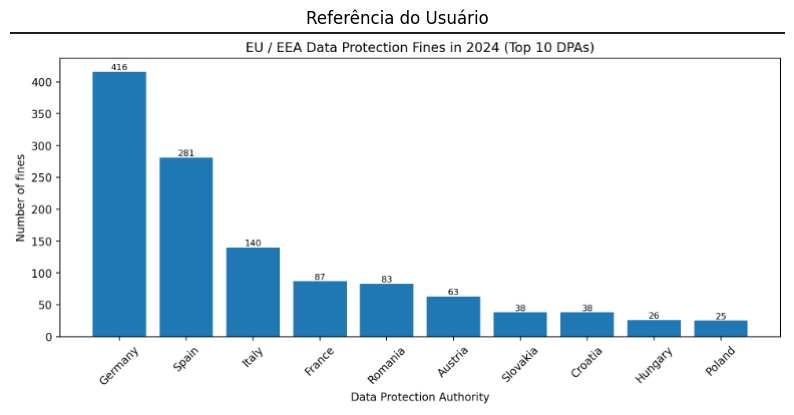

In [35]:
from PIL import Image
import matplotlib.pyplot as plt

# Abrindo a imagem enviada para identificar o padrão do gráfico
img_path = '/content/Captura de tela 2026-05-05 041759.png'
try:
    img = Image.open(img_path)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Referência do Usuário')
    plt.show()
except Exception as e:
    print(f'Erro ao carregar imagem: {e}')

In [36]:
import plotly.express as px
import pandas as pd
import re

# Preparação dos dados: contando as palavras nos títulos
text = ' '.join(df_db['title'].astype(str)).lower()
# Filtra palavras com mais de 4 letras para focar em termos significativos
words = re.findall(r'\b\w{5,}\b', text)

if words:
    word_counts = pd.Series(words).value_counts().reset_index()
    word_counts.columns = ['Word', 'Count']

    # Criando o Treemap estilo a referência
    fig = px.treemap(
        word_counts.head(25),
        path=['Word'],
        values='Count',
        color='Count',
        color_continuous_scale='Viridis',
        title='Principais Temas em Governança de Internet (Frequência de Palavras)'
    )

    fig.update_layout(
        margin=dict(t=50, l=10, r=10, b=10),
        font=dict(family="Arial", size=14)
    )

    fig.show()
else:
    print("Nenhum dado de texto encontrado para gerar o gráfico.")

In [38]:
import plotly.express as px
import pandas as pd
import re

# Data preparation: counting words in titles
text = ' '.join(df_db['title'].astype(str)).lower()
# Filter significant words with more than 4 letters
words = re.findall(r'\b\w{5,}\b', text)

if words:
    word_counts = pd.Series(words).value_counts().head(20).reset_index()
    word_counts.columns = ['Word', 'Frequency']

    # Sort so the largest bar is at the top
    word_counts = word_counts.sort_values(by='Frequency', ascending=True)

    # Creating the bar chart in English
    fig = px.bar(
        word_counts,
        x='Frequency',
        y='Word',
        orientation='h',
        title='Term Frequency in EDPB News Titles',
        color='Frequency',
        color_continuous_scale='Blues',
        text='Frequency'
    )

    fig.update_layout(
        height=700,
        margin=dict(t=50, l=10, r=10, b=10),
        font=dict(family="Arial", size=12),
        yaxis={'categoryorder':'total ascending'},
        plot_bgcolor='white',
        xaxis_title="Frequency",
        yaxis_title="Keyword"
    )

    fig.update_traces(textposition='outside')

    fig.show()
else:
    print("No data found to generate the bar chart.")

In [45]:
import pandas as pd
import re

# Join all paragraphs into a single text block
all_paragraphs_text = ' '.join(df_edpb['paragrafos'].astype(str)).lower()

# Extract words with more than 4 letters
words_paragraphs = re.findall(r'\b\w{5,}\b', all_paragraphs_text)

# List of words to exclude
exclude_words = [
    'following', 'chair', 'under', 'these', 'ensure', 'during', 'which', 'their',
    'further', 'between', 'should', 'draft', 'adopted', 'first', 'third', 'supervisory',
    'regarding', 'provide', 'basis'
]

# Filter out excluded words
filtered_words = [w for w in words_paragraphs if w not in exclude_words]

if filtered_words:
    # Calculate frequency
    paragraph_word_counts = pd.Series(filtered_words).value_counts().head(30).reset_index()
    paragraph_word_counts.columns = ['Term', 'Frequency']

    print("📊 Top 30 terms found in news paragraphs (filtered):")
    display(paragraph_word_counts)
else:
    print("⚠️ No text found in the paragraphs column to analyze.")

📊 Top 30 terms found in news paragraphs (filtered):


,Term,Frequency
0,protection,667
1,european,386
2,authorities,251
3,personal,248
4,board,244
5,guidelines,212
6,decision,198
7,processing,190
8,plenary,177
9,legal,160


In [47]:
import plotly.express as px

# Criando o Treemap com uma escala de cores mais variada e vibrante
if not paragraph_word_counts.empty:
    fig_treemap = px.treemap(
        paragraph_word_counts,
        path=['Term'],
        values='Frequency',
        color='Frequency',
        color_continuous_scale='Turbo',  # Escala 'Turbo' é muito mais colorida
        title='Principais Temas nos Parágrafos das Notícias do EDPB (Treemap Colorido)'
    )

    fig_treemap.update_layout(
        margin=dict(t=50, l=10, r=10, b=10),
        font=dict(family="Arial", size=16)
    )

    fig_treemap.show()
else:
    print("⚠️ Não há dados suficientes para gerar o gráfico.")

In [48]:
# Exibindo estatísticas descritivas da frequência dos termos
print("📊 Estatísticas Descritivas dos Top 30 Termos (Parágrafos):")
display(paragraph_word_counts['Frequency'].describe())

# Adicionalmente, mostrando a distribuição em percentual
total_words = paragraph_word_counts['Frequency'].sum()
paragraph_word_counts['Percentage (%)'] = (paragraph_word_counts['Frequency'] / total_words * 100).round(2)

print("\n📋 Tabela Detalhada com Percentual:")
display(paragraph_word_counts)

📊 Estatísticas Descritivas dos Top 30 Termos (Parágrafos):


,Frequency
count,30.000000
mean,163.766667
std,117.800440
min,75.000000
25%,93.250000
50%,134.500000
75%,186.750000
max,667.000000



📋 Tabela Detalhada com Percentual:


,Term,Frequency,Percentage (%)
0,protection,667,13.58
1,european,386,7.86
2,authorities,251,5.11
3,personal,248,5.05
4,board,244,4.97
5,guidelines,212,4.32
6,decision,198,4.03
7,processing,190,3.87
8,plenary,177,3.60
9,legal,160,3.26


In [51]:
import pandas as pd
import plotly.express as px

# 1. Cleaning and date conversion
def clean_edpb_date(data_str):
    if pd.isna(data_str) or data_str == 'NA':
        return None
    try:
        # EDPB usually uses ISO or strings that pandas converts well
        return pd.to_datetime(data_str).to_period('M').to_timestamp()
    except:
        return None

df_temp = df_edpb.copy()
df_temp['dt_clean'] = df_temp['data'].apply(clean_edpb_date)

# 2. Identify terms in each news item
top_5_terms = paragraph_word_counts['Term'].head(5).tolist()

for term in top_5_terms:
    df_temp[term] = df_temp['paragrafos'].str.contains(term, case=False, na=False).astype(int)

# 3. Group by date (if available)
df_trend = df_temp.dropna(subset=['dt_clean']).groupby('dt_clean')[top_5_terms].sum().reset_index()

if not df_trend.empty:
    fig_corr = px.line(
        df_trend,
        x='dt_clean',
        y=top_5_terms,
        title='Evolution of Top 5 Terms Over Time',
        labels={'dt_clean': 'Date', 'value': 'Frequency', 'variable': 'Term'}
    )
    fig_corr.show()
else:
    print('⚠️ Captured dates are insufficient for a line chart. Displaying count by ID as a chronological proxy:')
    df_temp['id_proxy'] = df_temp.index
    df_rolling = df_temp[top_5_terms].rolling(window=20).sum()
    df_rolling['id_proxy'] = df_temp['id_proxy']

    fig_proxy = px.line(
        df_rolling.dropna(),
        x='id_proxy',
        y=top_5_terms,
        title='Term Trends (Moving Average by Collection Order)',
        labels={'id_proxy': 'News Sequence (Recent -> Older)', 'value': 'Frequency (Moving Average)', 'variable': 'Term'}
    )
    fig_proxy.show()

⚠️ Captured dates are insufficient for a line chart. Displaying count by ID as a chronological proxy:


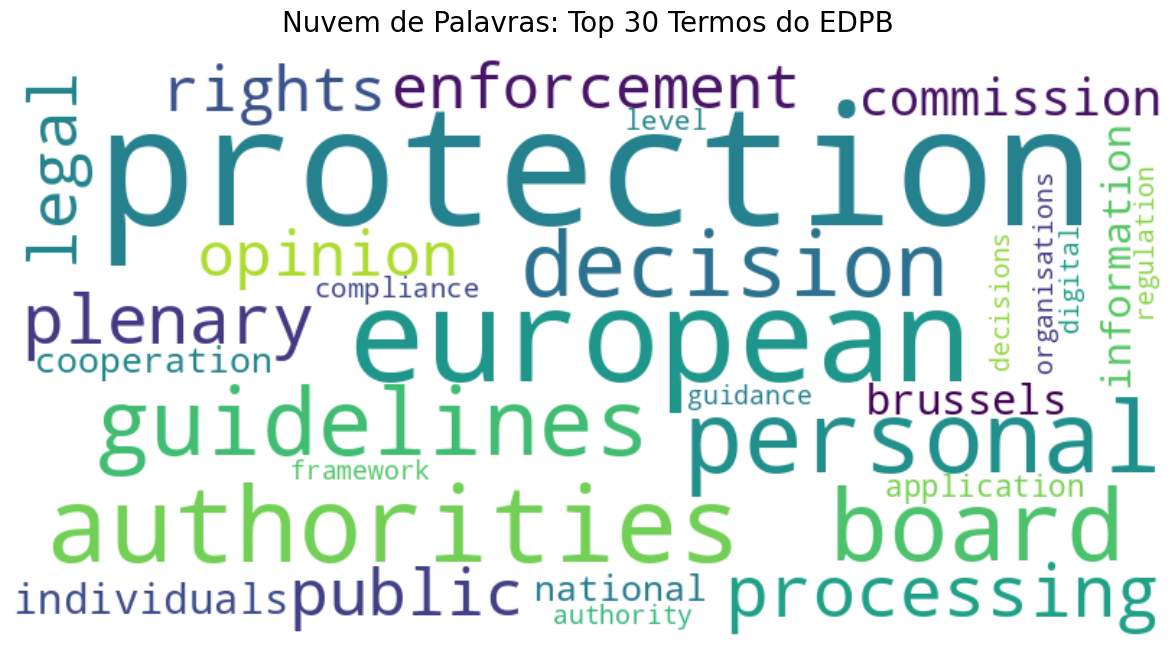

In [50]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Criando um dicionário de frequências a partir do DataFrame
terms_dict = dict(zip(paragraph_word_counts['Term'], paragraph_word_counts['Frequency']))

# Gerando a nuvem de palavras
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    max_words=30
).generate_from_frequencies(terms_dict)

# Exibindo o gráfico
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nuvem de Palavras: Top 30 Termos do EDPB', fontsize=20, pad=20)
plt.show()